In [1]:
from MFDFA_functions import get_generalised_hurst, get_mf_spectrum
import numpy as np
import matplotlib.pyplot as plt
from MFDFA_new import MFDFA
from MFDFA_classes import MFDFA_Analysis_Empirical, MFDFA_Analysis_Empirical_D_only
import pandas as pd
from iaaft import surrogates

/Users/alexvillamartin/Documents/MSc Diss/Code/MFDFA_classes.py:255: SyntaxWarning: invalid escape sequence '\s'
  SE(\bar{f_alpha}) = \frac{\sigma_{f_alpha}}{\sqrt{n}})
/Users/alexvillamartin/Documents/MSc Diss/Code/MFDFA_classes.py:757: SyntaxWarning: invalid escape sequence '\s'
  RV = \sum_{i=1}^{n} r_i^2 where n is number of returns in the day.
/Users/alexvillamartin/Documents/MSc Diss/Code/MFDFA_classes.py:1418: SyntaxWarning: invalid escape sequence '\s'
  RV = \sum_{i=1}^{n} r_i^2 where n is number of returns in the day.


In [12]:
euro_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_S5_EURUSD.parquet")
sgd_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_S5_USDSGD.parquet")
euro_d = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_EURUSD.parquet")
sgd_d = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_USDSGD.parquet")
datas = [euro_d, sgd_d, euro_s5, sgd_s5]
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'daily_intraday_volatility']
names = ['EURUSD_D', 'USDSGD_D', 'EURUSD_S5', 'USDSGD_S5']

analyser = MFDFA_Analysis_Empirical(datas=datas,
                                    fraction_of_s5=2, # use np.inf to use all data
                                    s_min_d=10,
                                    s_min_s5=10,
                                    q_min=-50,
                                    q_max=50,
                                    m=1,
                                    steps=10,
                                    type=types[2],
                                    models=names,
                                    plots=True,
                                    end_trading_hr_euro=18,
                                    end_trading_hr_sgd=18,
                                    start_trading_hr_euro=6,
                                    start_trading_hr_sgd=2,
                                    unit_test=False, 
                                    shuffle=False, 
                                    compare_to_shuffle_ind=False, 
                                    n_surrogates=1000,
                                    accuracy_surrogates=5.0)

df = analyser.clean_data()

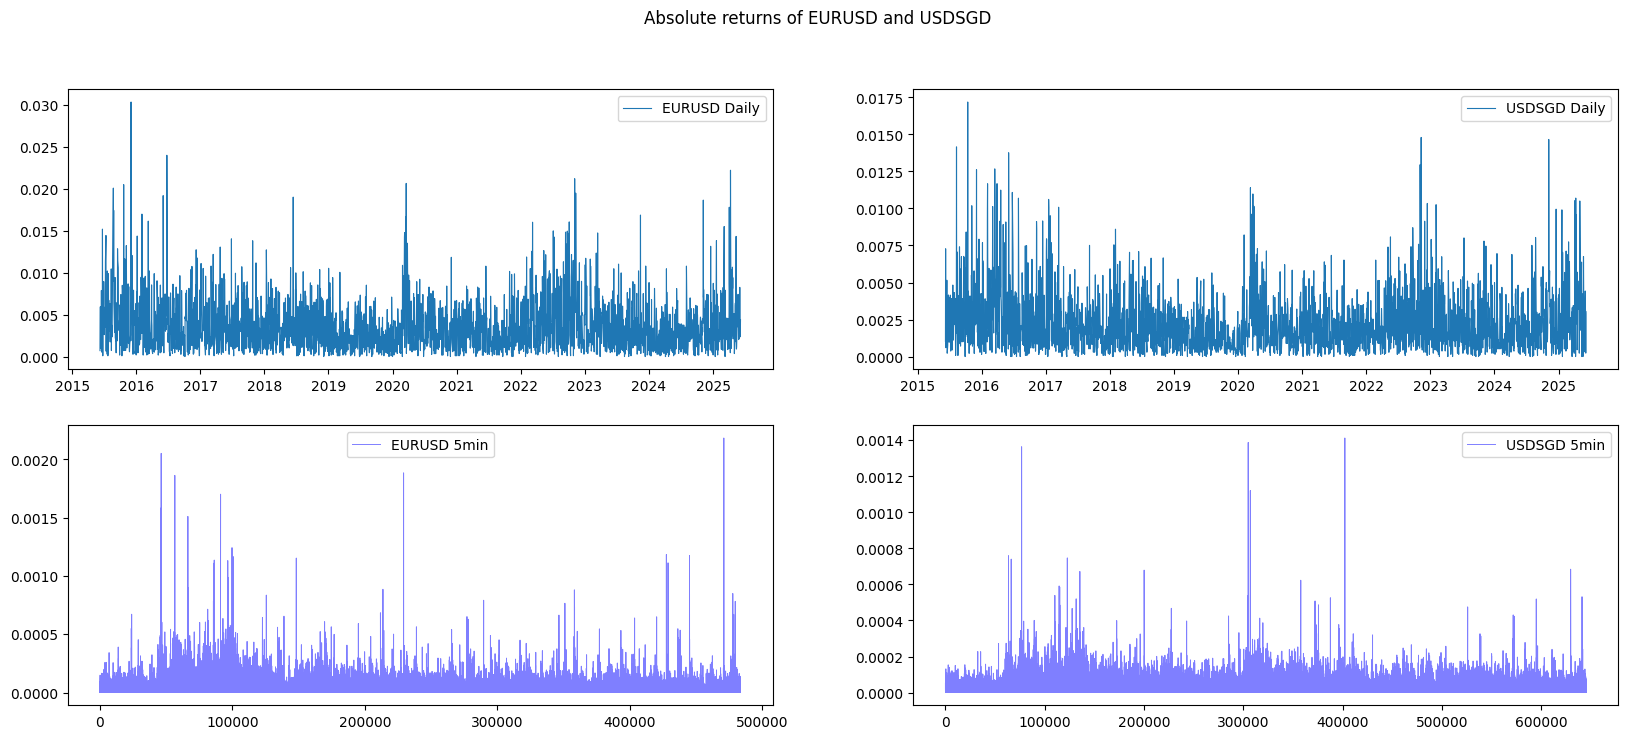

In [30]:
euro_s5 = df[2]
sgd_s5 = df[3]
euro_d = df[0]
sgd_d = df[1]

plt.figure(figsize=(20, 8))
plt.subplot(2, 2, 1)
plt.plot(euro_d.index, np.abs(euro_d), label='EURUSD Daily', linewidth = 0.8)
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(sgd_d.index, np.abs(sgd_d), label='USDSGD Daily', linewidth = 0.8)
plt.legend()

plt.subplot(2, 2, 3)
x = np.arange(len(euro_s5))
plt.plot(x, np.abs(euro_s5), label='EURUSD 5min', color = 'b', linewidth = 0.7, alpha = 0.5)
plt.legend()

plt.subplot(2, 2, 4)
x = np.arange(len(sgd_s5))
plt.plot(x, np.abs(sgd_s5), label='USDSGD 5min', color = 'b', linewidth = 0.7, alpha = 0.5)
plt.legend()

plt.suptitle('Absolute returns of EURUSD and USDSGD')
plt.show()

Do it in same one otherwise we shorten or apply transformations to series more than once. 

In [2]:
euro_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_S5_EURUSD.parquet")
sgd_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_S5_USDSGD.parquet")
euro_d = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_EURUSD.parquet")
sgd_d = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_USDSGD.parquet")
datas = [euro_d, sgd_d, euro_s5, sgd_s5]
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'daily_intraday_volatility']
names = ['EURUSD_D', 'USDSGD_D', 'EURUSD_S5', 'USDSGD_S5']

analyser = MFDFA_Analysis_Empirical(datas=datas,
                                    fraction_of_s5=2, # use np.inf to use all data
                                    s_min_d=10,
                                    s_min_s5=10,
                                    q_min=-50,
                                    q_max=50,
                                    m=1,
                                    steps=10,
                                    type=types[0],
                                    models=names,
                                    plots=True,
                                    end_trading_hr_euro=18,
                                    end_trading_hr_sgd=18,
                                    start_trading_hr_euro=6,
                                    start_trading_hr_sgd=2,
                                    unit_test=False, 
                                    shuffle=False, 
                                    compare_to_shuffle_ind=False, 
                                    n_surrogates=1000,
                                    accuracy_surrogates=5.0)

ps_r, hursts_surr_r, alphas_surr_r, f_alphas_surr_r, taos_surr_r, df_surr_r = analyser.surrogate_tests()

Generating surrogates for model EURUSD_D


Estim100%|██████████████████████████████| 1000/1000 [00:18<00:00, 55.26it/s]


Generating surrogates for model USDSGD_D


Estim100%|██████████████████████████████| 1000/1000 [00:22<00:00, 44.75it/s]


Generating surrogates for model EURUSD_S5


Estim100%|██████████████████████████████| 1000/1000 [2:42:19<00:00,  9.74s/it] 


Generating surrogates for model USDSGD_S5


Estim100%|██████████████████████████████| 1000/1000 [5:23:03<00:00, 19.38s/it] 


In [3]:
np.savez("empirical_surrogate_tests_raw_log_r.npz", p_values=ps_r)

In [17]:
np.savez("empirical_surrogate_data_raw_log_r.npz", 
         EURUSD_D=df_surr_r[0], 
         USDSGD_D=df_surr_r[1], 
         EURUSD_S5=df_surr_r[2], 
         USDSGD_S5=df_surr_r[3])

np.savez("empirical_surrogate_MF_raw_log_r.npz", hursts=hursts_surr_r, alphas=alphas_surr_r, f_alphas=f_alphas_surr_r, taos=taos_surr_r)

In [28]:
len(alphas_surr_r[0])

1000

In [2]:
import numpy as np

In [3]:
X = np.load("empirical_surrogate_tests_raw_log_r.npz")['p_values']

In [4]:
X

array([0.65534466, 0.00899101, 0.000999  , 0.000999  ])

In [ ]:
euro_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_S5_EURUSD.parquet")
sgd_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_S5_USDSGD.parquet")
euro_d = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_EURUSD.parquet")
sgd_d = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_USDSGD.parquet")
datas = [euro_d, sgd_d]#, euro_s5[:100000], sgd_s5[:100000]]
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'daily_intraday_volatility']
names = ['EURUSD_D', 'USDSGD_D']#, 'EURUSD_S5', 'USDSGD_S5']

analyser = MFDFA_Analysis_Empirical_D_only(datas=datas,
                                    fraction_of_s5=2, # use np.inf to use all data
                                    s_min_d=10,
                                    s_min_s5=10,
                                    q_min=-50,
                                    q_max=50,
                                    m=1,
                                    steps=10,
                                    type=types[1],
                                    models=names,
                                    plots=True,
                                    end_trading_hr_euro=18,
                                    end_trading_hr_sgd=18,
                                    start_trading_hr_euro=6,
                                    start_trading_hr_sgd=2,
                                    unit_test=False, 
                                    shuffle=False, 
                                    compare_to_shuffle_ind=False, 
                                    n_surrogates=1000,
                                    accuracy_surrogates=5.0)

ps_squ_r, hursts_surr_squ_r, alphas_surr_squ_r, f_alphas_surr_squ_r, taos_surr_squ_r, df_surr_squ_r = analyser.surrogate_tests()

Generating surrogates for model EURUSD_D


Estim100%|██████████████████████████████| 1000/1000 [04:27<00:00,  3.73it/s]


Generating surrogates for model USDSGD_D


Estim100%|██████████████████████████████| 1000/1000 [04:08<00:00,  4.03it/s]
/Users/alexvillamartin/Documents/MSc Diss/Code/MFDFA_new.py:253: RuntimeWarning: overflow encountered in float_power
  np.mean(np.float_power(F, q_safe / 2)),
/Users/alexvillamartin/Documents/MSc Diss/Code/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:135: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


In [7]:
ps_squ_r

[array(0.39360639), array(0.72527473)]

In [ ]:
np.savez("empirical_surrogate_tests_squared_returns.npz", p_values=ps_squ_r)

# Save surrogate data separately for each dataset since they have different shapes
np.savez("empirical_surrogate_data_squared_returns.npz", 
         EURUSD_D=df_surr_squ_r[0], 
         USDSGD_D=df_surr_squ_r[1], 
         EURUSD_S5=df_surr_squ_r[2], 
         USDSGD_S5=df_surr_squ_r[3])

np.savez("empirical_surrogate_MF_squared_returns.npz", hursts=hursts_surr_squ_r, alphas=alphas_surr_squ_r, f_alphas=f_alphas_surr_squ_r, taos=taos_surr_squ_r)

In [8]:
euro_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_S5_EURUSD.parquet")
sgd_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_S5_USDSGD.parquet")
euro_d = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_EURUSD.parquet")
sgd_d = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_USDSGD.parquet")
datas = [euro_d, sgd_d]#, euro_s5, sgd_s5]
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'daily_intraday_volatility']
names = ['EURUSD_D', 'USDSGD_D']#, 'EURUSD_S5', 'USDSGD_S5']

analyser = MFDFA_Analysis_Empirical_D_only(datas=datas,
                                    fraction_of_s5=2, # use np.inf to use all data
                                    s_min_d=10,
                                    s_min_s5=10,
                                    q_min=-50,
                                    q_max=50,
                                    m=1,
                                    steps=10,
                                    type=types[2],
                                    models=names,
                                    plots=True,
                                    end_trading_hr_euro=18,
                                    end_trading_hr_sgd=18,
                                    start_trading_hr_euro=6,
                                    start_trading_hr_sgd=2,
                                    unit_test=False, 
                                    shuffle=False, 
                                    compare_to_shuffle_ind=False, 
                                    n_surrogates=1000,
                                    accuracy_surrogates=5.0)

ps_abs_r, hursts_surr_abs_r, alphas_surr_abs_r, f_alphas_surr_abs_r, taos_surr_abs_r, df_surr_abs_r = analyser.surrogate_tests()

Generating surrogates for model EURUSD_D


Estim100%|██████████████████████████████| 1000/1000 [00:40<00:00, 24.51it/s]


Generating surrogates for model USDSGD_D


Estim100%|██████████████████████████████| 1000/1000 [00:51<00:00, 19.51it/s]


In [9]:
ps_abs_r

[array(0.50849151), array(0.1958042)]

In [ ]:
np.savez("empirical_surrogate_tests_absolute_returns.npz", p_values=ps_abs_r)

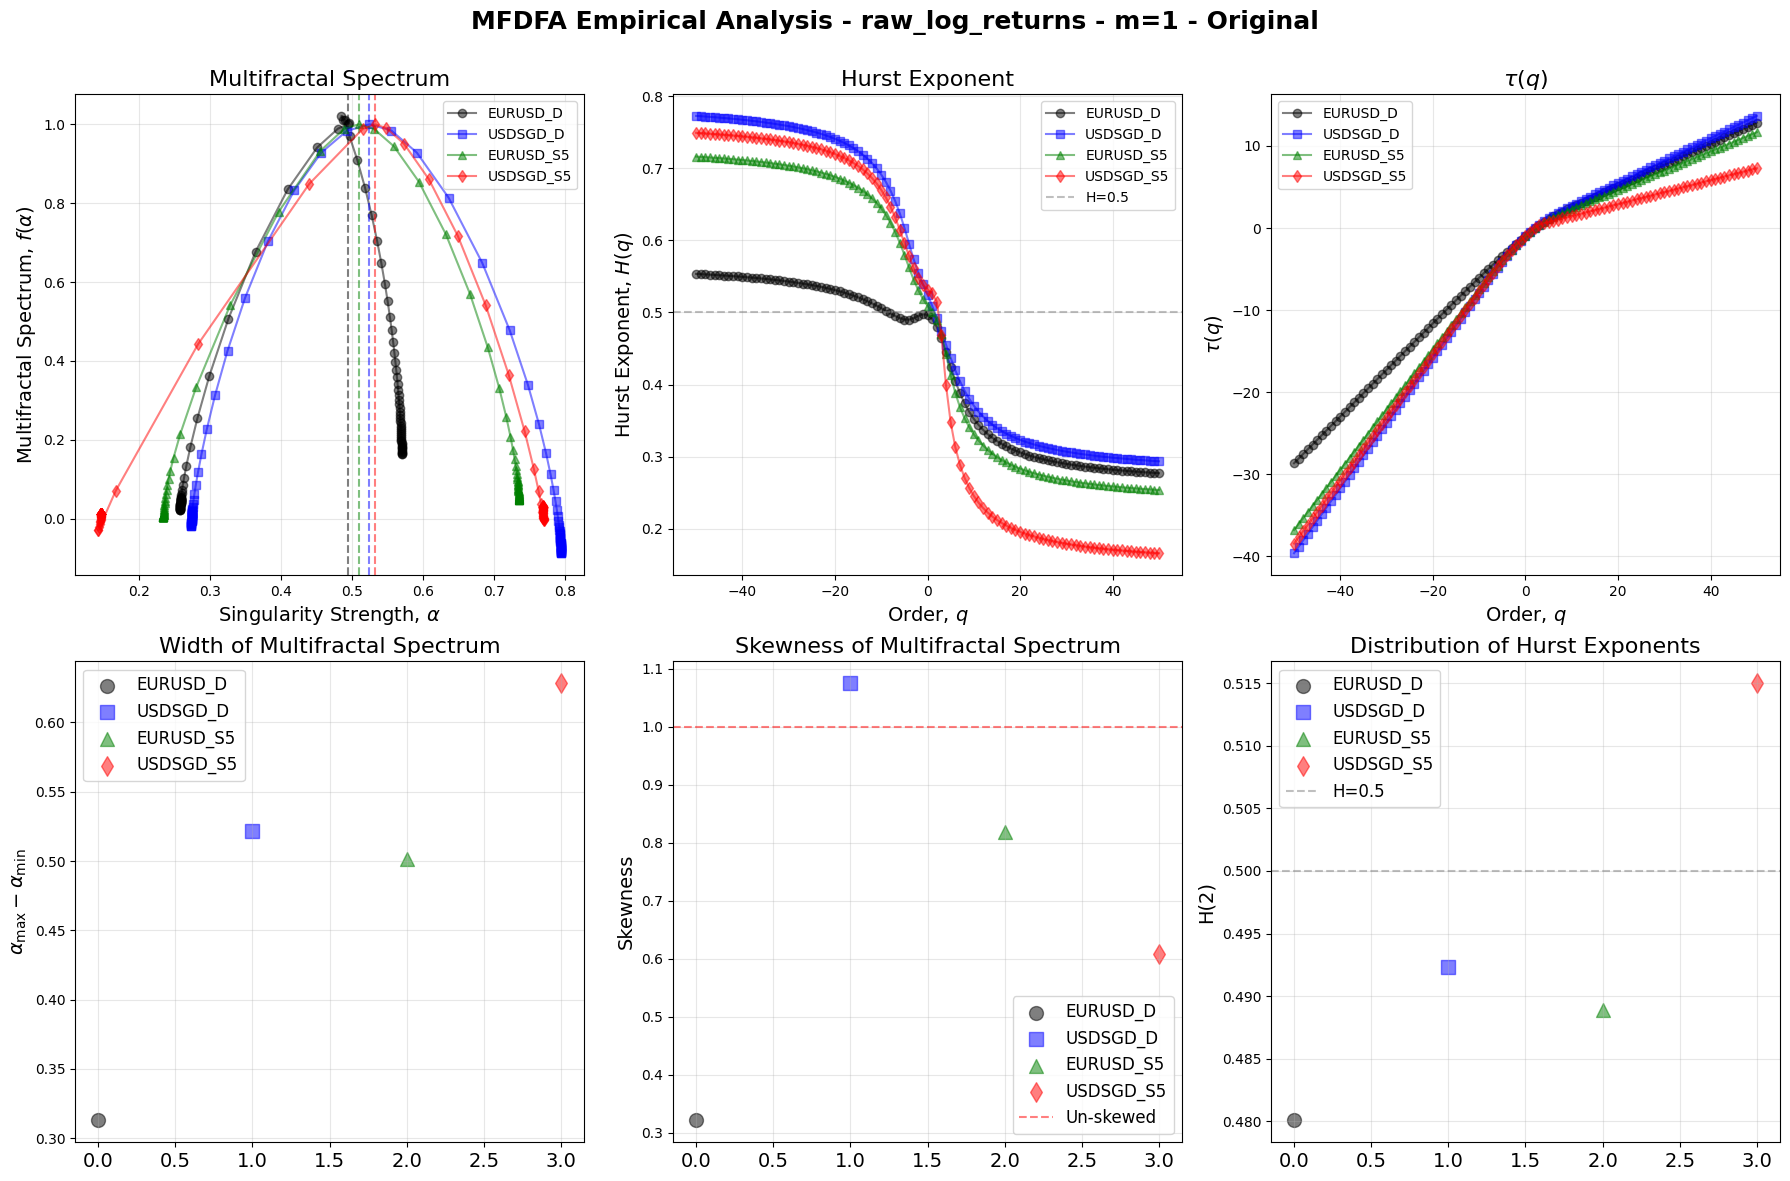

In [2]:
euro_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_S5_EURUSD.parquet")
sgd_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_S5_USDSGD.parquet")
euro_d = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_EURUSD.parquet")
sgd_d = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_USDSGD.parquet")
datas = [euro_d, sgd_d, euro_s5, sgd_s5]
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'daily_intraday_volatility']
names = ['EURUSD_D', 'USDSGD_D', 'EURUSD_S5', 'USDSGD_S5']

analyser = MFDFA_Analysis_Empirical(datas=datas,
                                    fraction_of_s5=2, # use np.inf to use all data
                                    s_min_d=10,
                                    s_min_s5=10,
                                    q_min=-50,
                                    q_max=50,
                                    m=1,
                                    steps=10,
                                    type=types[0],
                                    models=names,
                                    plots=True,
                                    end_trading_hr_euro=18,
                                    end_trading_hr_sgd=18,
                                    start_trading_hr_euro=6,
                                    start_trading_hr_sgd=2,
                                    unit_test=False, 
                                    shuffle=False, 
                                    compare_to_shuffle_ind=False, 
                                    n_surrogates=1000,
                                    accuracy_surrogates=5.0)

analyser.get_plots()

In [ ]:
euro_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_S5_EURUSD.parquet")
sgd_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_S5_USDSGD.parquet")
euro_d = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_EURUSD.parquet")
sgd_d = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_USDSGD.parquet")
datas = [euro_d, sgd_d, euro_s5, sgd_s5]
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'daily_intraday_volatility']
names = ['EURUSD_D', 'USDSGD_D', 'EURUSD_S5', 'USDSGD_S5']

analyser = MFDFA_Analysis_Empirical(datas=datas,
                                    fraction_of_s5=2, # use np.inf to use all data
                                    s_min_d=10,
                                    s_min_s5=10,
                                    q_min=-50,
                                    q_max=50,
                                    m=2,
                                    steps=10,
                                    type=types[0],
                                    models=names,
                                    plots=True,
                                    end_trading_hr_euro=18,
                                    end_trading_hr_sgd=18,
                                    start_trading_hr_euro=6,
                                    start_trading_hr_sgd=2,
                                    unit_test=False, 
                                    shuffle=False, 
                                    compare_to_shuffle_ind=False, 
                                    n_surrogates=1000,
                                    accuracy_surrogates=5.0)

analyser.get_plots()

/Users/alexvillamartin/Documents/MSc Diss/Code/MFDFA_new.py:253: RuntimeWarning: overflow encountered in float_power
  np.mean(np.float_power(F, q_safe / 2)),
/Users/alexvillamartin/Documents/MSc Diss/Code/MFDFA_functions.py:120: RuntimeWarning: divide by zero encountered in log
  log_Fq = np.log(F_q)


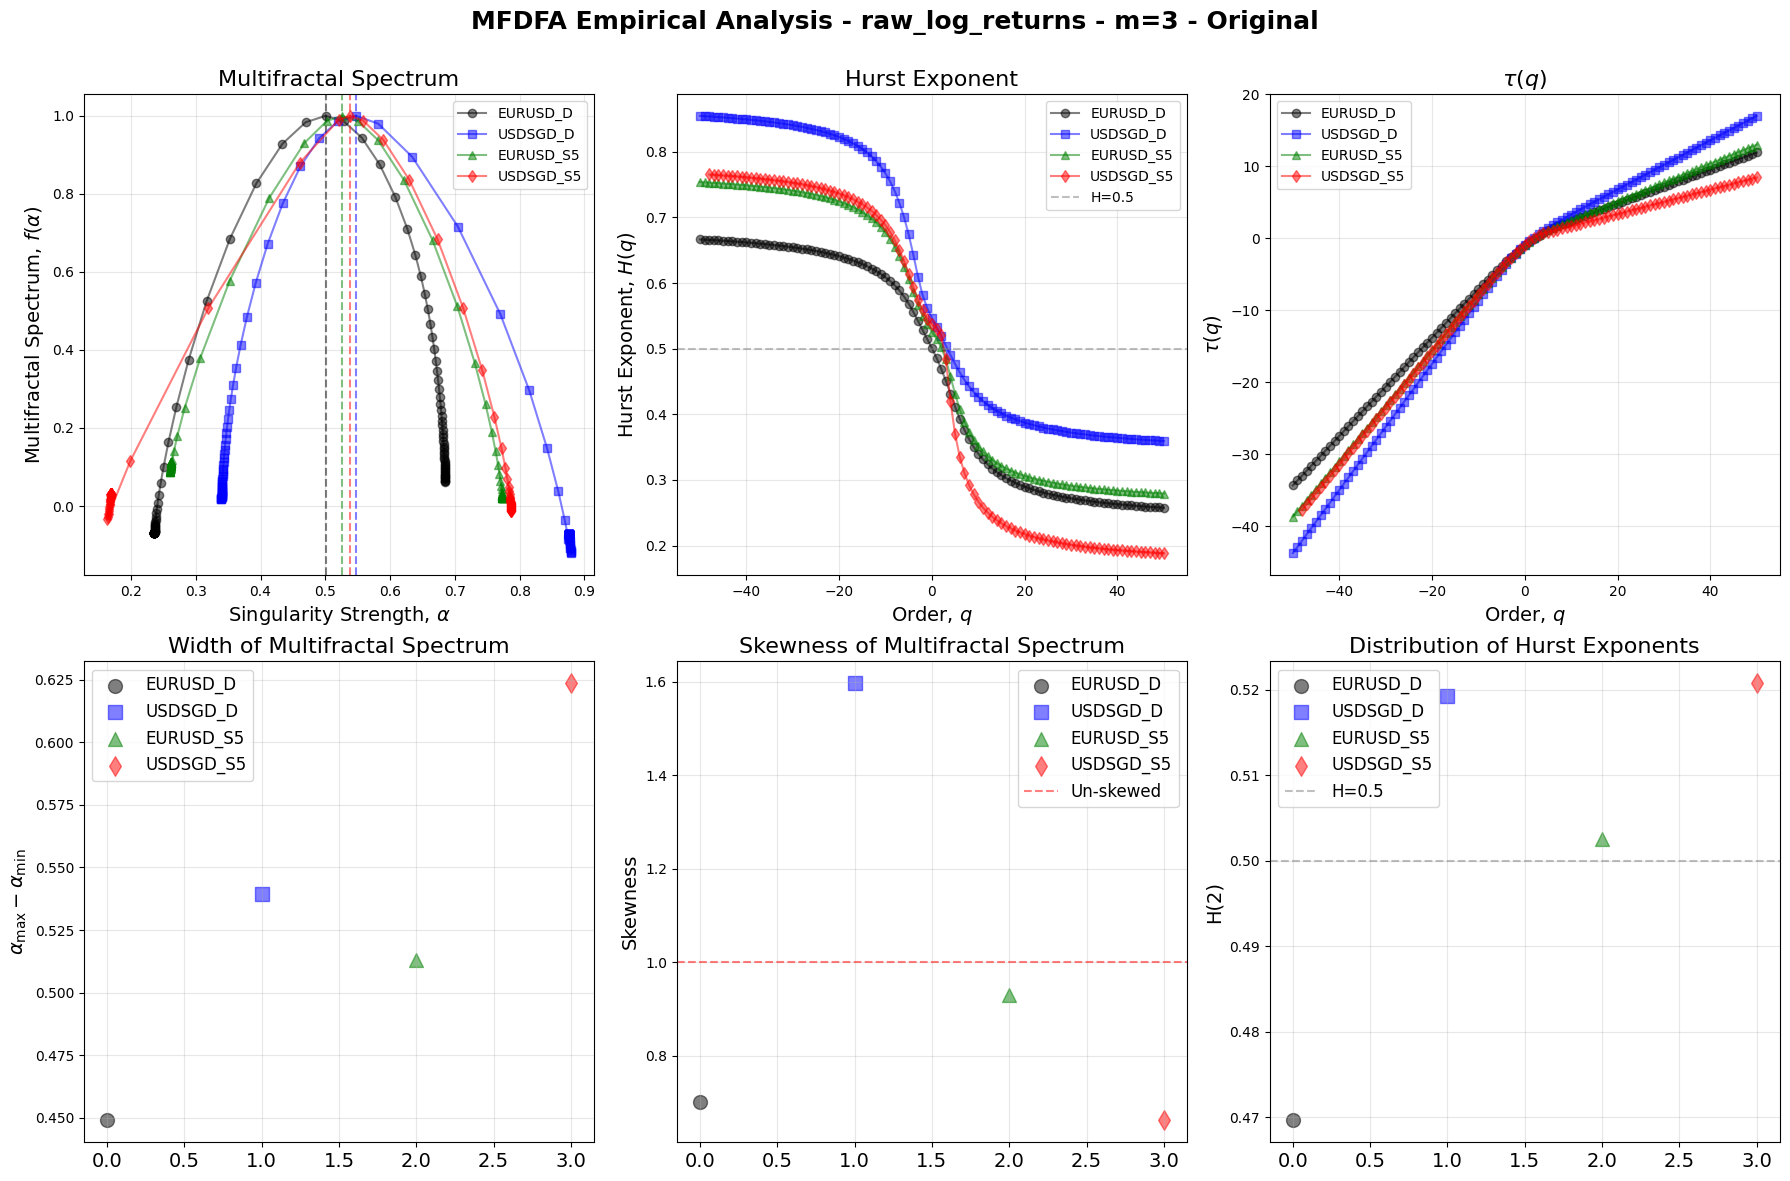

In [3]:
euro_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_S5_EURUSD.parquet")
sgd_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_S5_USDSGD.parquet")
euro_d = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_EURUSD.parquet")
sgd_d = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_USDSGD.parquet")
datas = [euro_d, sgd_d, euro_s5, sgd_s5]
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'daily_intraday_volatility']
names = ['EURUSD_D', 'USDSGD_D', 'EURUSD_S5', 'USDSGD_S5']

analyser = MFDFA_Analysis_Empirical(datas=datas,
                                    fraction_of_s5=2, # use np.inf to use all data
                                    s_min_d=10,
                                    s_min_s5=10,
                                    q_min=-50,
                                    q_max=50,
                                    m=3,
                                    steps=10,
                                    type=types[0],
                                    models=names,
                                    plots=True,
                                    end_trading_hr_euro=18,
                                    end_trading_hr_sgd=18,
                                    start_trading_hr_euro=6,
                                    start_trading_hr_sgd=2,
                                    unit_test=False, 
                                    shuffle=False, 
                                    compare_to_shuffle_ind=False, 
                                    n_surrogates=1000,
                                    accuracy_surrogates=5.0)

analyser.get_plots()

/Users/alexvillamartin/Documents/MSc Diss/Code/MFDFA_new.py:253: RuntimeWarning: overflow encountered in float_power
  np.mean(np.float_power(F, q_safe / 2)),
/Users/alexvillamartin/Documents/MSc Diss/Code/MFDFA_functions.py:120: RuntimeWarning: divide by zero encountered in log
  log_Fq = np.log(F_q)
/Users/alexvillamartin/Documents/MSc Diss/Code/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:135: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


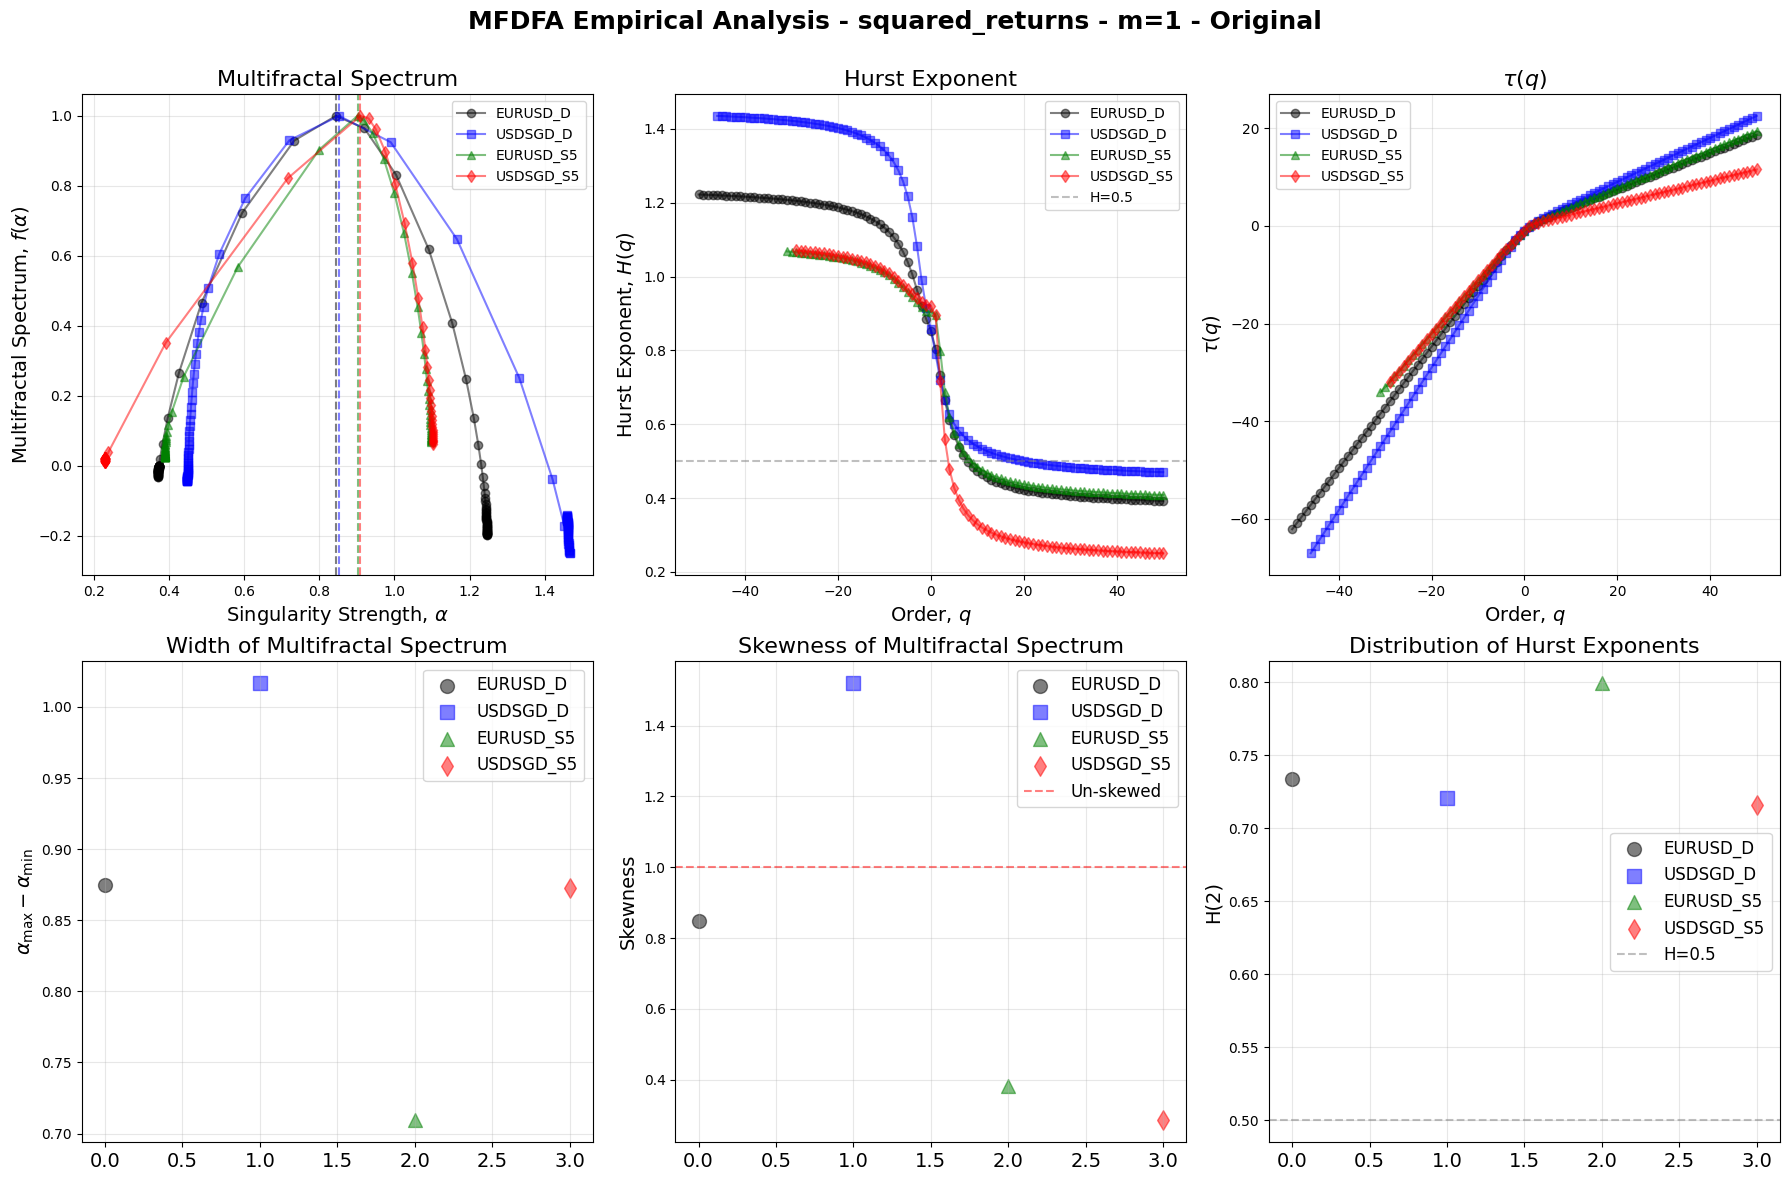

In [4]:
euro_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_S5_EURUSD.parquet")
sgd_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_S5_USDSGD.parquet")
euro_d = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_EURUSD.parquet")
sgd_d = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_USDSGD.parquet")
datas = [euro_d, sgd_d, euro_s5, sgd_s5]
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'daily_intraday_volatility']
names = ['EURUSD_D', 'USDSGD_D', 'EURUSD_S5', 'USDSGD_S5']

analyser = MFDFA_Analysis_Empirical(datas=datas,
                                    fraction_of_s5=2, # use np.inf to use all data
                                    s_min_d=10,
                                    s_min_s5=10,
                                    q_min=-50,
                                    q_max=50,
                                    m=1,
                                    steps=10,
                                    type=types[1],
                                    models=names,
                                    plots=True,
                                    end_trading_hr_euro=18,
                                    end_trading_hr_sgd=18,
                                    start_trading_hr_euro=6,
                                    start_trading_hr_sgd=2,
                                    unit_test=False, 
                                    shuffle=False, 
                                    compare_to_shuffle_ind=False, 
                                    n_surrogates=1000,
                                    accuracy_surrogates=5.0)

analyser.get_plots()

In [ ]:
euro_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_S5_EURUSD.parquet")
sgd_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_S5_USDSGD.parquet")
euro_d = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_EURUSD.parquet")
sgd_d = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_USDSGD.parquet")
datas = [euro_d, sgd_d, euro_s5, sgd_s5]
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'daily_intraday_volatility']
names = ['EURUSD_D', 'USDSGD_D', 'EURUSD_S5', 'USDSGD_S5']

analyser = MFDFA_Analysis_Empirical(datas=datas,
                                    fraction_of_s5=2, # use np.inf to use all data
                                    s_min_d=10,
                                    s_min_s5=10,
                                    q_min=-50,
                                    q_max=50,
                                    m=2,
                                    steps=10,
                                    type=types[1],
                                    models=names,
                                    plots=True,
                                    end_trading_hr_euro=18,
                                    end_trading_hr_sgd=18,
                                    start_trading_hr_euro=6,
                                    start_trading_hr_sgd=2,
                                    unit_test=False, 
                                    shuffle=False, 
                                    compare_to_shuffle_ind=False, 
                                    n_surrogates=1000,
                                    accuracy_surrogates=5.0)

analyser.get_plots()

/Users/alexvillamartin/Documents/MSc Diss/Code/MFDFA_new.py:253: RuntimeWarning: overflow encountered in float_power
  np.mean(np.float_power(F, q_safe / 2)),
/Users/alexvillamartin/Documents/MSc Diss/Code/MFDFA_functions.py:120: RuntimeWarning: divide by zero encountered in log
  log_Fq = np.log(F_q)
/Users/alexvillamartin/Documents/MSc Diss/Code/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:135: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


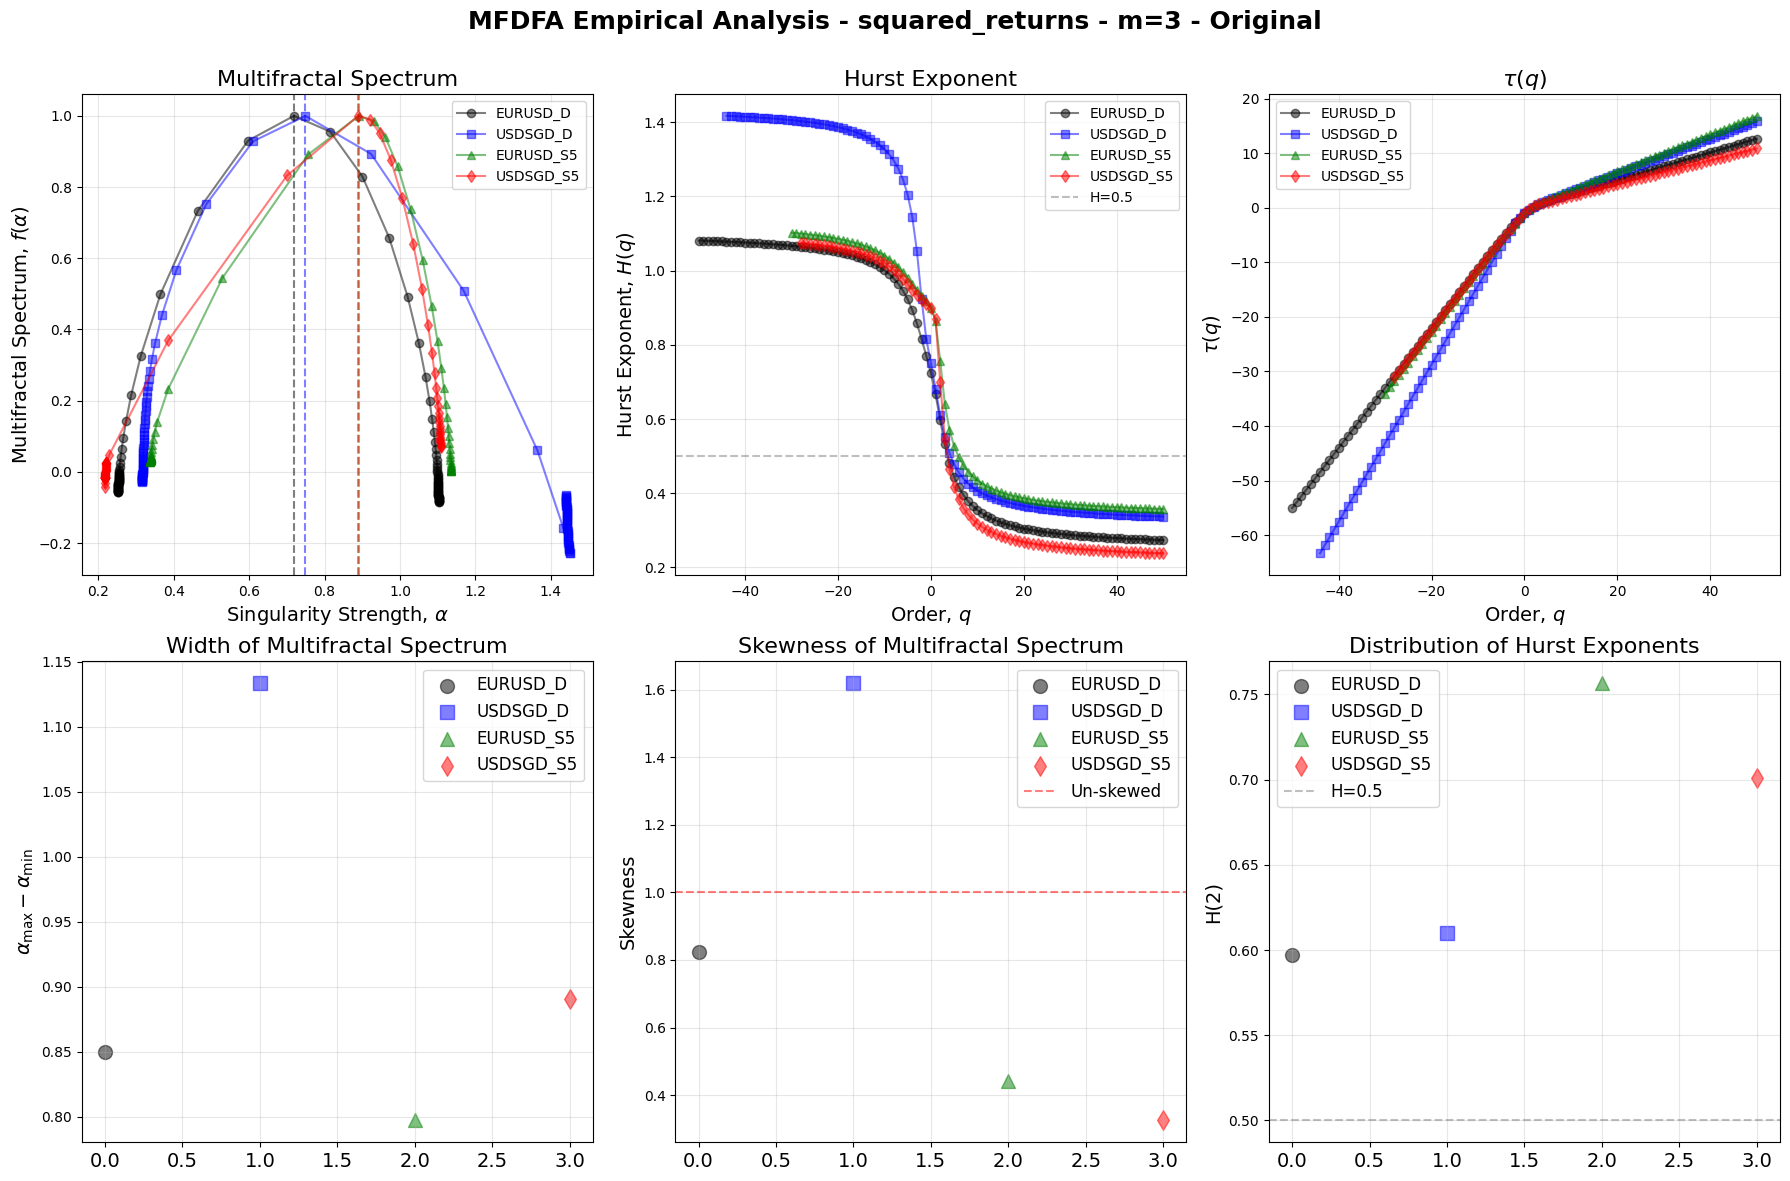

In [5]:
euro_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_S5_EURUSD.parquet")
sgd_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_S5_USDSGD.parquet")
euro_d = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_EURUSD.parquet")
sgd_d = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_USDSGD.parquet")
datas = [euro_d, sgd_d, euro_s5, sgd_s5]
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'daily_intraday_volatility']
names = ['EURUSD_D', 'USDSGD_D', 'EURUSD_S5', 'USDSGD_S5']

analyser = MFDFA_Analysis_Empirical(datas=datas,
                                    fraction_of_s5=2, # use np.inf to use all data
                                    s_min_d=10,
                                    s_min_s5=10,
                                    q_min=-50,
                                    q_max=50,
                                    m=3,
                                    steps=10,
                                    type=types[1],
                                    models=names,
                                    plots=True,
                                    end_trading_hr_euro=18,
                                    end_trading_hr_sgd=18,
                                    start_trading_hr_euro=6,
                                    start_trading_hr_sgd=2,
                                    unit_test=False, 
                                    shuffle=False, 
                                    compare_to_shuffle_ind=False, 
                                    n_surrogates=1000,
                                    accuracy_surrogates=5.0)

analyser.get_plots()

/Users/alexvillamartin/Documents/MSc Diss/Code/MFDFA_new.py:253: RuntimeWarning: overflow encountered in float_power
  np.mean(np.float_power(F, q_safe / 2)),
/Users/alexvillamartin/Documents/MSc Diss/Code/MFDFA_functions.py:120: RuntimeWarning: divide by zero encountered in log
  log_Fq = np.log(F_q)


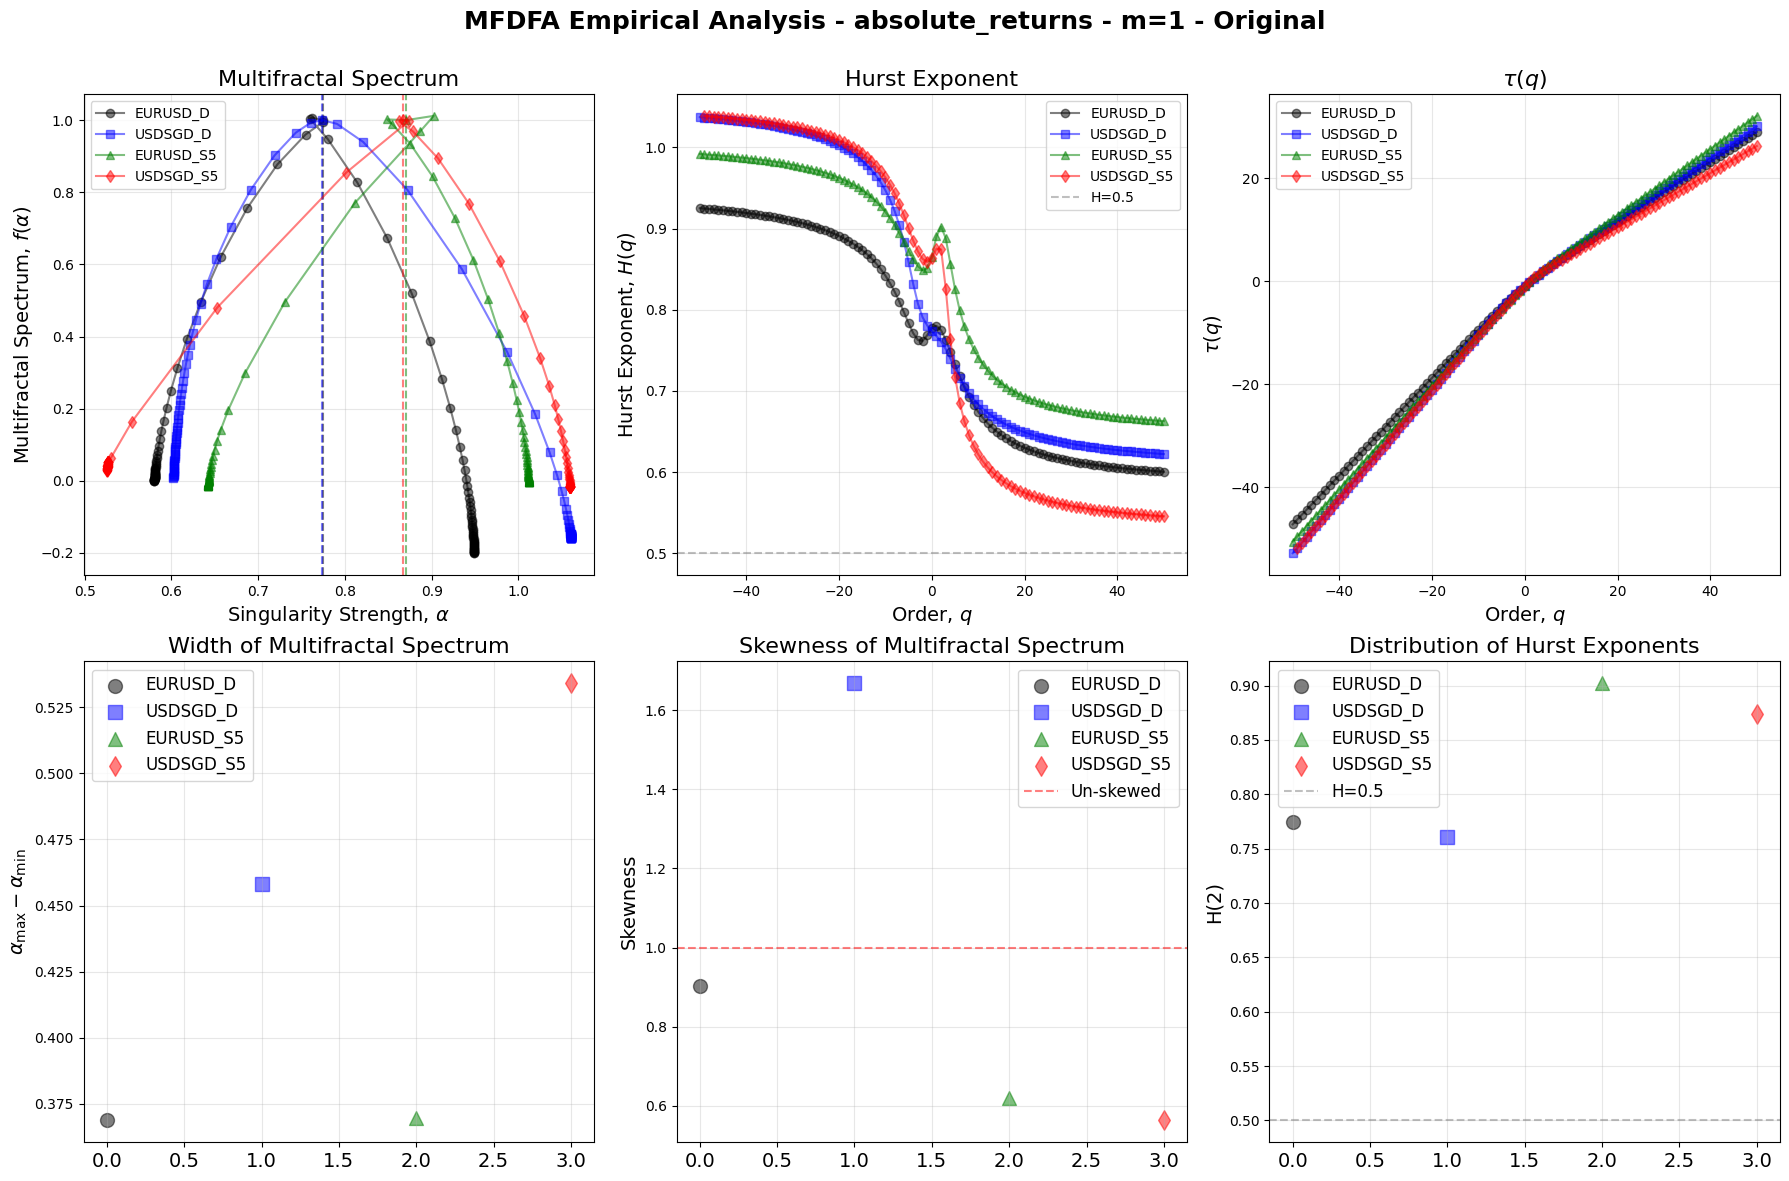

In [6]:
euro_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_S5_EURUSD.parquet")
sgd_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_S5_USDSGD.parquet")
euro_d = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_EURUSD.parquet")
sgd_d = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_USDSGD.parquet")
datas = [euro_d, sgd_d, euro_s5, sgd_s5]
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'daily_intraday_volatility']
names = ['EURUSD_D', 'USDSGD_D', 'EURUSD_S5', 'USDSGD_S5']

analyser = MFDFA_Analysis_Empirical(datas=datas,
                                    fraction_of_s5=2, # use np.inf to use all data
                                    s_min_d=10,
                                    s_min_s5=10,
                                    q_min=-50,
                                    q_max=50,
                                    m=1,
                                    steps=10,
                                    type=types[2],
                                    models=names,
                                    plots=True,
                                    end_trading_hr_euro=18,
                                    end_trading_hr_sgd=18,
                                    start_trading_hr_euro=6,
                                    start_trading_hr_sgd=2,
                                    unit_test=False, 
                                    shuffle=False, 
                                    compare_to_shuffle_ind=False, 
                                    n_surrogates=1000,
                                    accuracy_surrogates=5.0)

analyser.get_plots()

In [ ]:
euro_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_S5_EURUSD.parquet")
sgd_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_S5_USDSGD.parquet")
euro_d = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_EURUSD.parquet")
sgd_d = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_USDSGD.parquet")
datas = [euro_d, sgd_d, euro_s5, sgd_s5]
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'daily_intraday_volatility']
names = ['EURUSD_D', 'USDSGD_D', 'EURUSD_S5', 'USDSGD_S5']

analyser = MFDFA_Analysis_Empirical(datas=datas,
                                    fraction_of_s5=2, # use np.inf to use all data
                                    s_min_d=10,
                                    s_min_s5=10,
                                    q_min=-50,
                                    q_max=50,
                                    m=2,
                                    steps=10,
                                    type=types[2],
                                    models=names,
                                    plots=True,
                                    end_trading_hr_euro=18,
                                    end_trading_hr_sgd=18,
                                    start_trading_hr_euro=6,
                                    start_trading_hr_sgd=2,
                                    unit_test=False, 
                                    shuffle=False, 
                                    compare_to_shuffle_ind=False, 
                                    n_surrogates=1000,
                                    accuracy_surrogates=5.0)

analyser.get_plots()

/Users/alexvillamartin/Documents/MSc Diss/Code/MFDFA_new.py:253: RuntimeWarning: overflow encountered in float_power
  np.mean(np.float_power(F, q_safe / 2)),
/Users/alexvillamartin/Documents/MSc Diss/Code/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:135: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/Users/alexvillamartin/Documents/MSc Diss/Code/MFDFA_functions.py:120: RuntimeWarning: divide by zero encountered in log
  log_Fq = np.log(F_q)


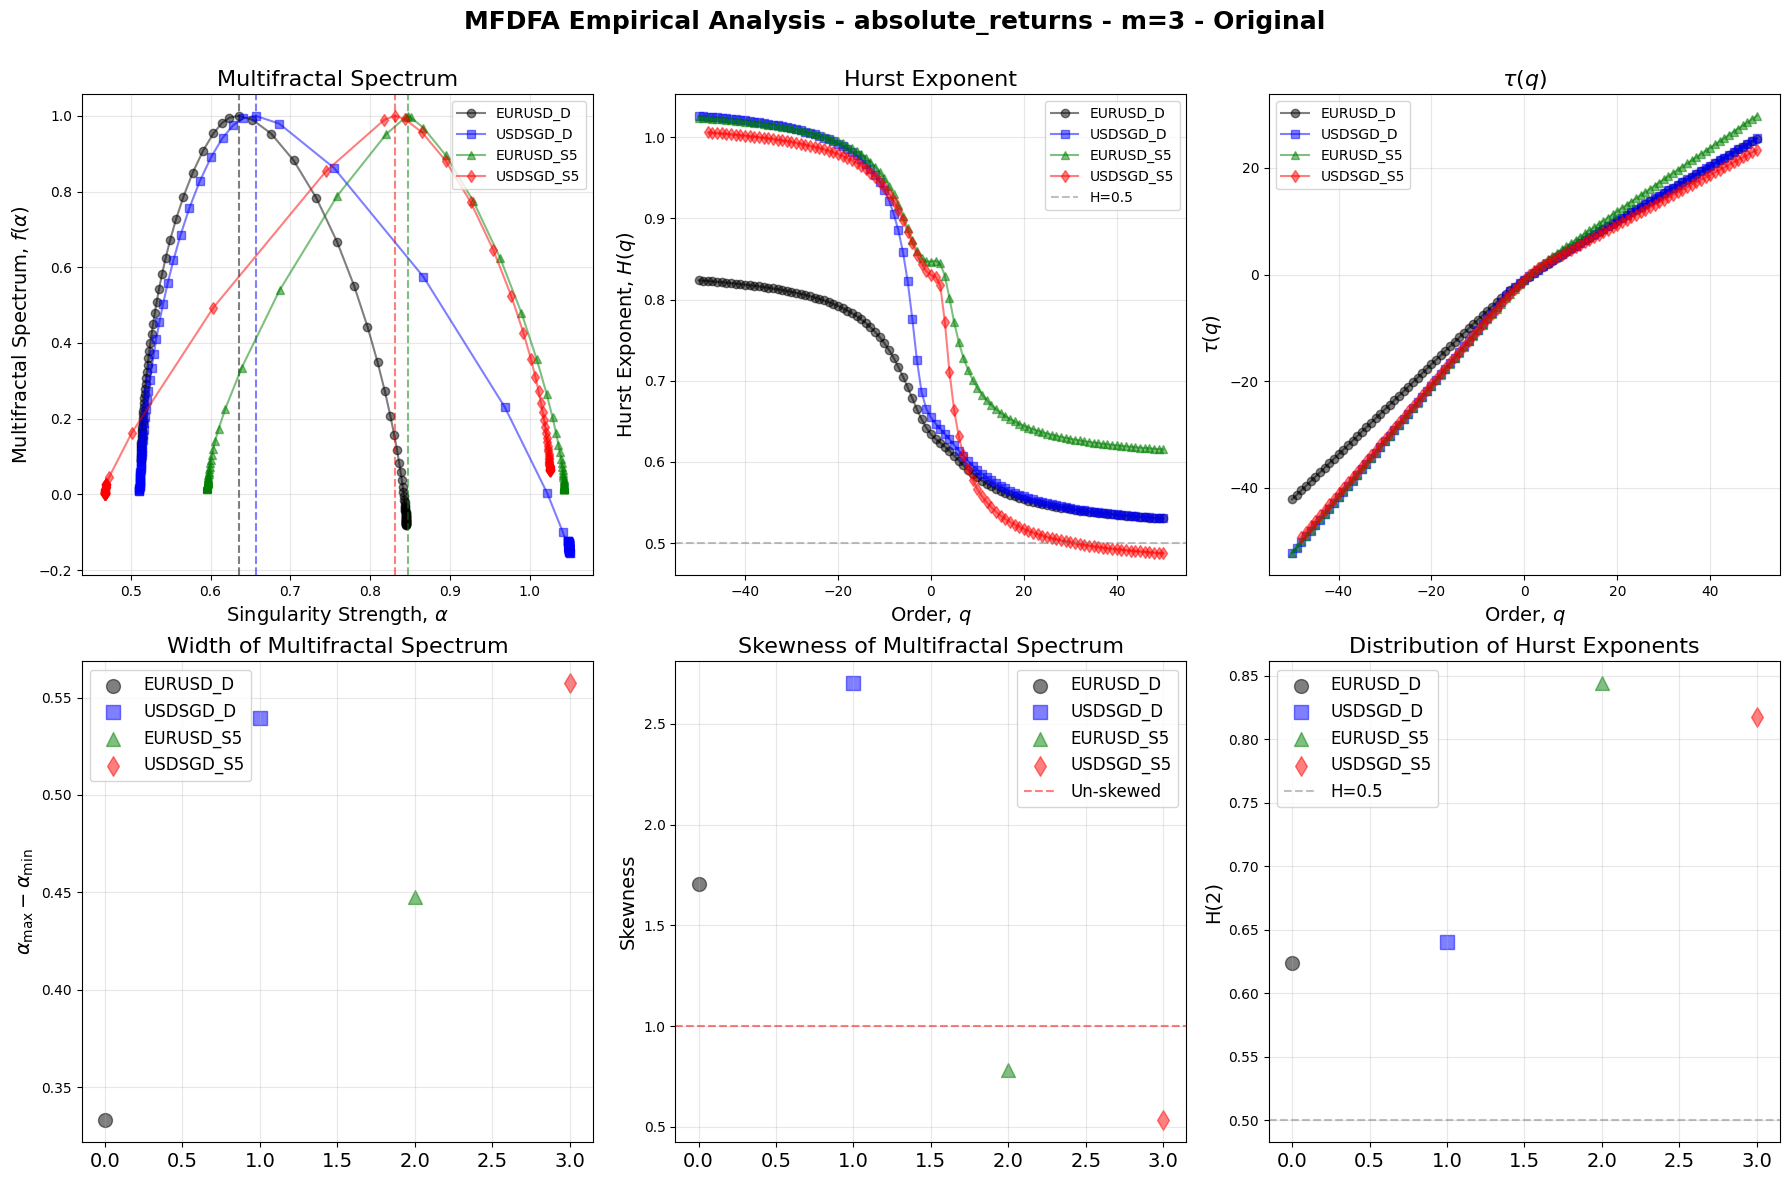

In [7]:
euro_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_S5_EURUSD.parquet")
sgd_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_S5_USDSGD.parquet")
euro_d = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_EURUSD.parquet")
sgd_d = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_USDSGD.parquet")
datas = [euro_d, sgd_d, euro_s5, sgd_s5]
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'daily_intraday_volatility']
names = ['EURUSD_D', 'USDSGD_D', 'EURUSD_S5', 'USDSGD_S5']

analyser = MFDFA_Analysis_Empirical(datas=datas,
                                    fraction_of_s5=2, # use np.inf to use all data
                                    s_min_d=10,
                                    s_min_s5=10,
                                    q_min=-50,
                                    q_max=50,
                                    m=3,
                                    steps=10,
                                    type=types[2],
                                    models=names,
                                    plots=True,
                                    end_trading_hr_euro=18,
                                    end_trading_hr_sgd=18,
                                    start_trading_hr_euro=6,
                                    start_trading_hr_sgd=2,
                                    unit_test=False, 
                                    shuffle=False, 
                                    compare_to_shuffle_ind=False, 
                                    n_surrogates=1000,
                                    accuracy_surrogates=5.0)

analyser.get_plots()

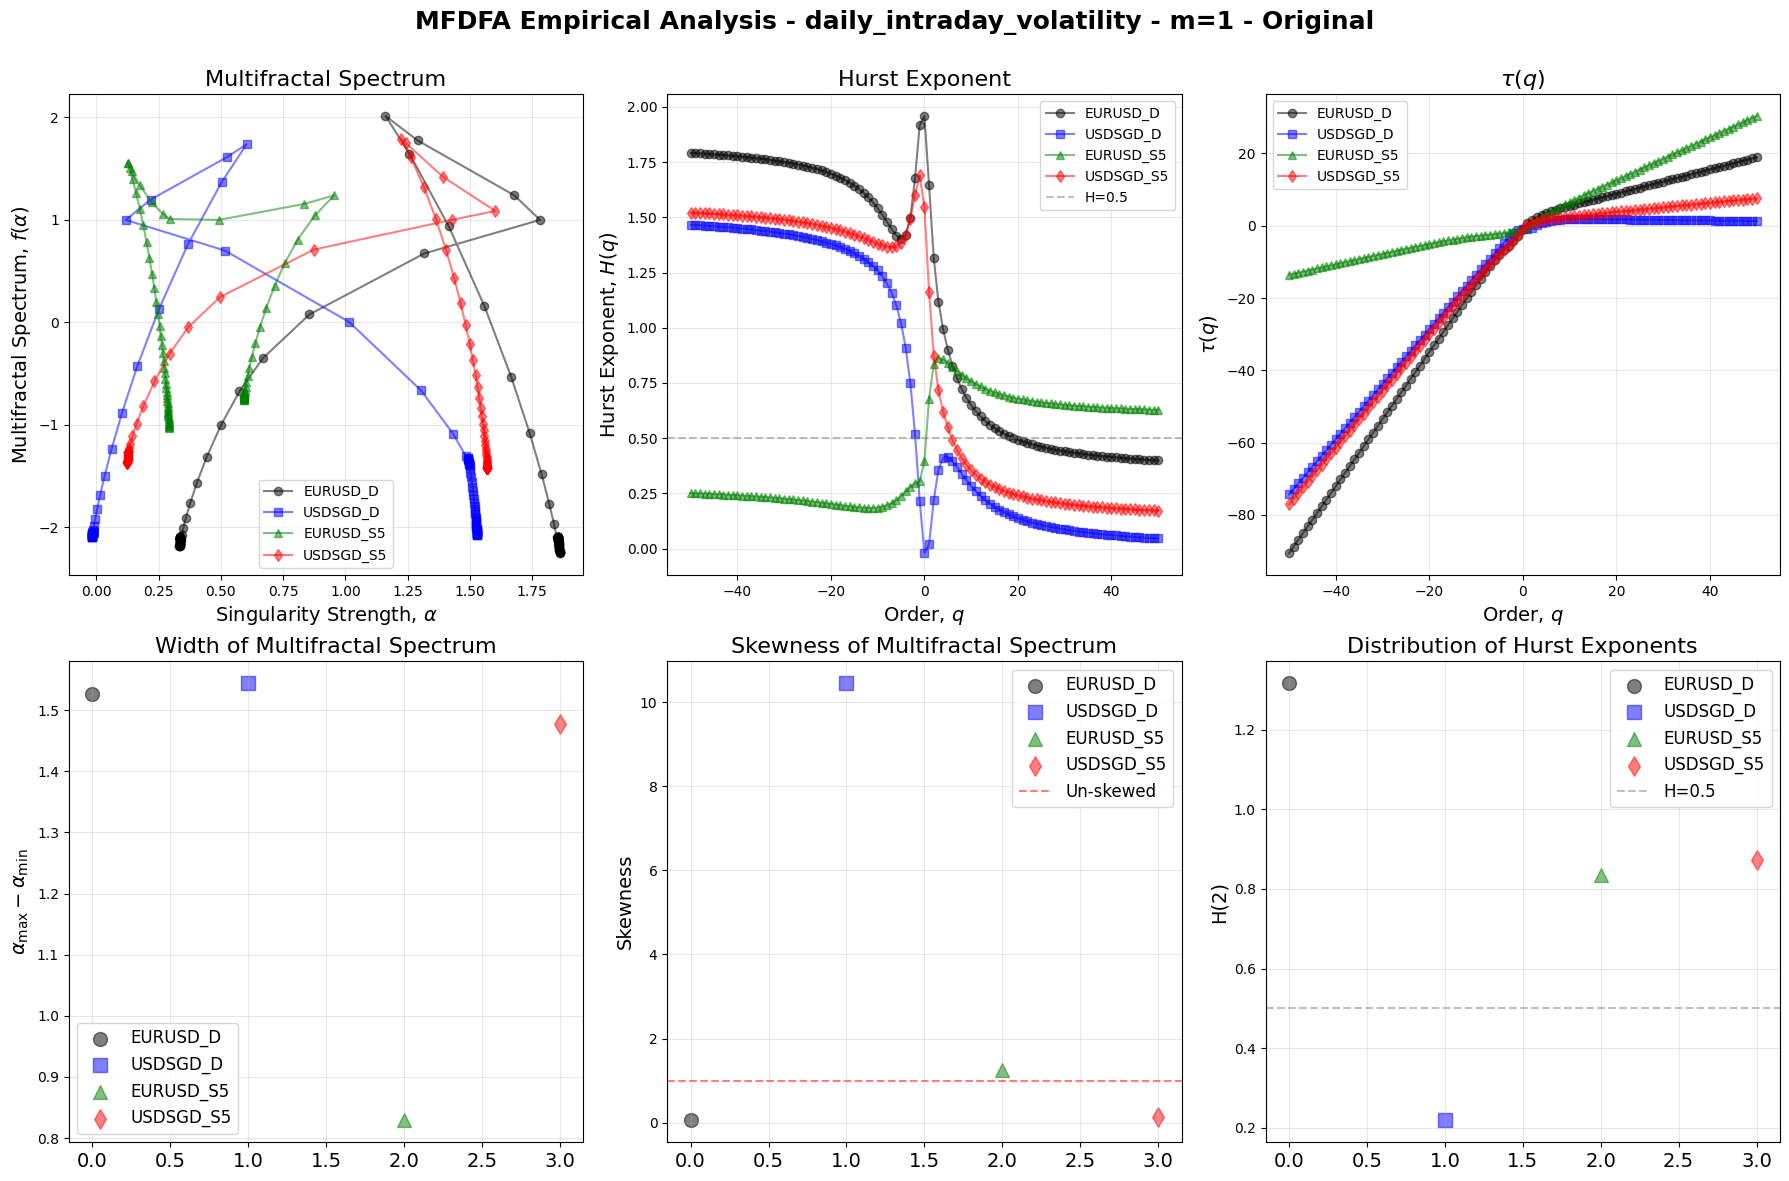

In [8]:
euro_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_S5_EURUSD.parquet")
sgd_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_S5_USDSGD.parquet")
euro_d = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_EURUSD.parquet")
sgd_d = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_USDSGD.parquet")
datas = [euro_d, sgd_d, euro_s5, sgd_s5]
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'daily_intraday_volatility']
names = ['EURUSD_D', 'USDSGD_D', 'EURUSD_S5', 'USDSGD_S5']

analyser = MFDFA_Analysis_Empirical(datas=datas,
                                    fraction_of_s5=2, # use np.inf to use all data
                                    s_min_d=10,
                                    s_min_s5=10,
                                    q_min=-50,
                                    q_max=50,
                                    m=1,
                                    steps=10,
                                    type=types[3],
                                    models=names,
                                    plots=True,
                                    end_trading_hr_euro=18,
                                    end_trading_hr_sgd=18,
                                    start_trading_hr_euro=6,
                                    start_trading_hr_sgd=2,
                                    unit_test=False, 
                                    shuffle=False, 
                                    compare_to_shuffle_ind=False, 
                                    n_surrogates=1000,
                                    accuracy_surrogates=5.0)

analyser.get_plots()


In [ ]:
euro_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_S5_EURUSD.parquet")
sgd_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_S5_USDSGD.parquet")
euro_d = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_EURUSD.parquet")
sgd_d = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_USDSGD.parquet")
datas = [euro_d, sgd_d, euro_s5, sgd_s5]
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'daily_intraday_volatility']
names = ['EURUSD_D', 'USDSGD_D', 'EURUSD_S5', 'USDSGD_S5']

analyser = MFDFA_Analysis_Empirical(datas=datas,
                                    fraction_of_s5=2, # use np.inf to use all data
                                    s_min_d=10,
                                    s_min_s5=10,
                                    q_min=-50,
                                    q_max=50,
                                    m=2,
                                    steps=10,
                                    type=types[3],
                                    models=names,
                                    plots=True,
                                    end_trading_hr_euro=18,
                                    end_trading_hr_sgd=18,
                                    start_trading_hr_euro=6,
                                    start_trading_hr_sgd=2,
                                    unit_test=False, 
                                    shuffle=False, 
                                    compare_to_shuffle_ind=False, 
                                    n_surrogates=1000,
                                    accuracy_surrogates=5.0)

analyser.get_plots()


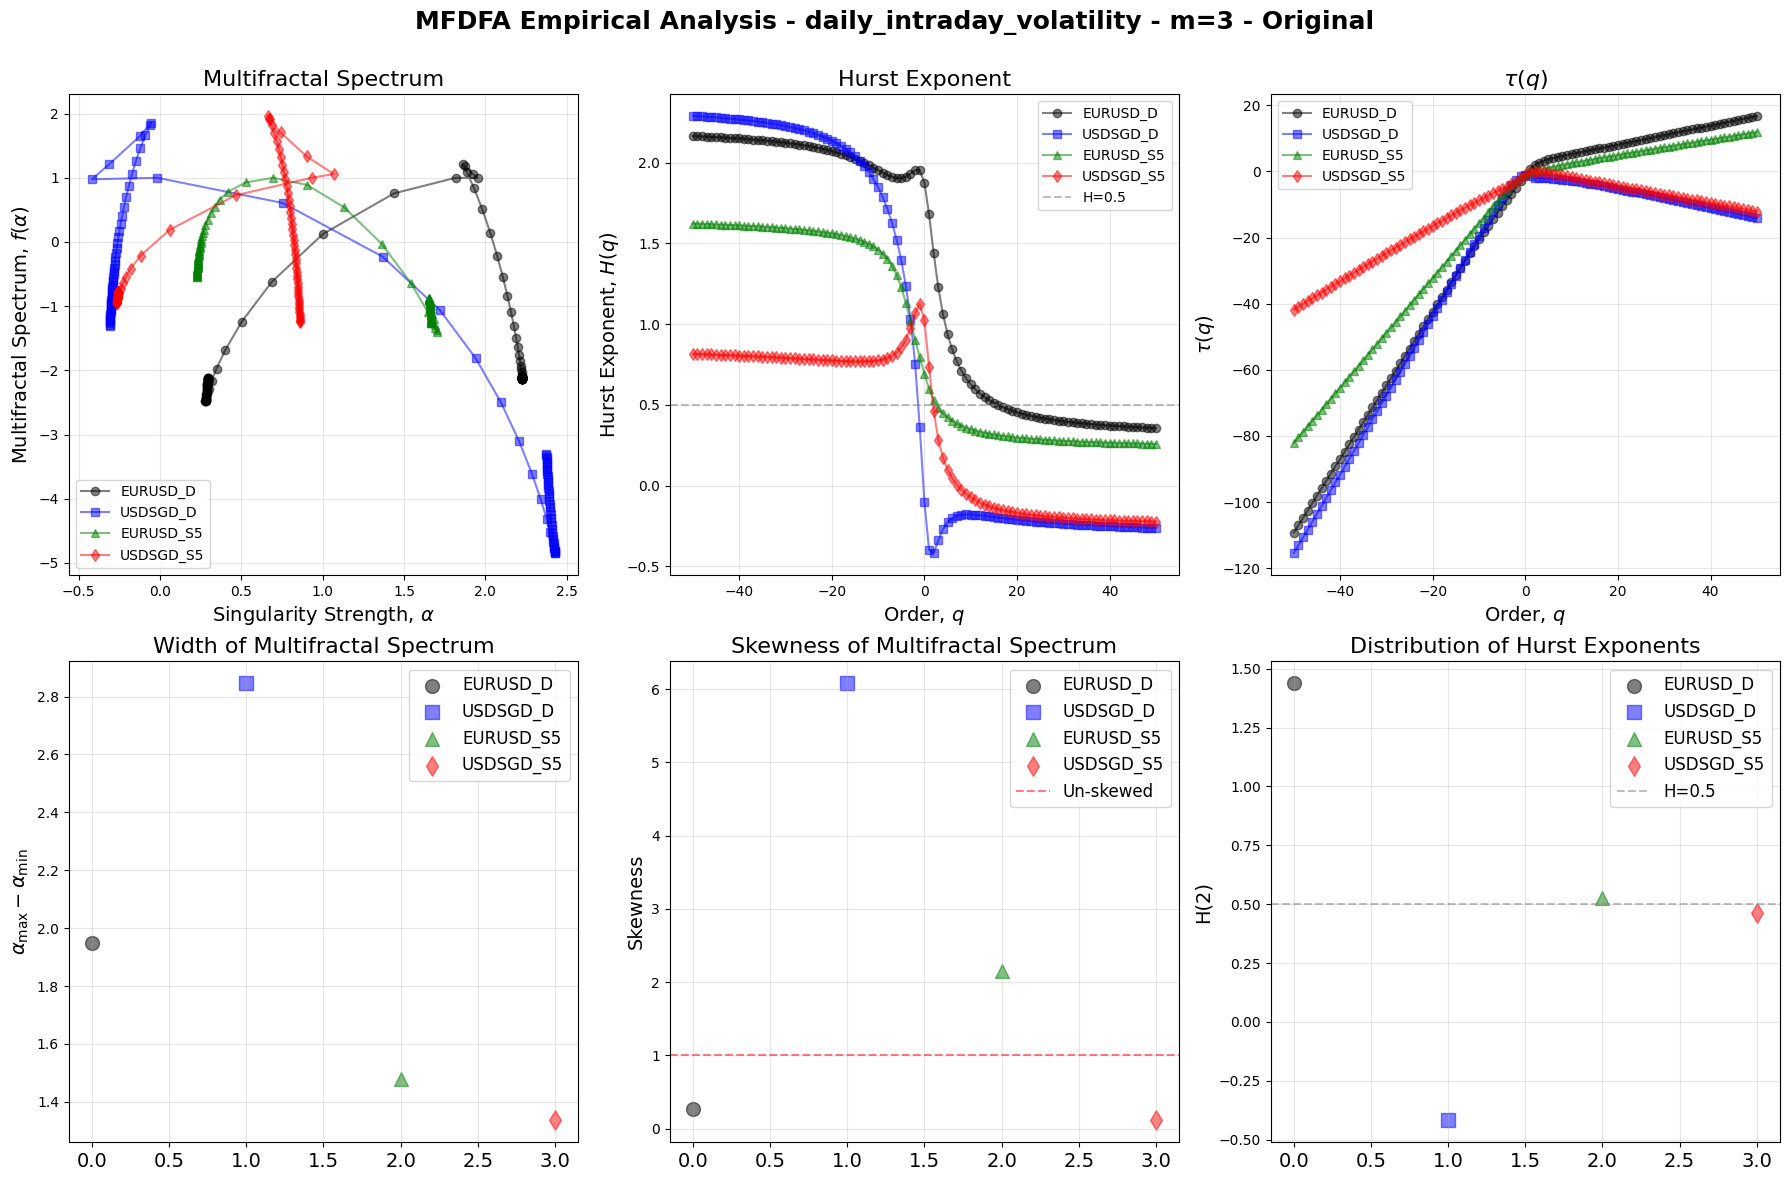

In [9]:
euro_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_S5_EURUSD.parquet")
sgd_s5 = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_S5_USDSGD.parquet")
euro_d = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_EURUSD.parquet")
sgd_d = pd.read_parquet("/Users/alexvillamartin/Documents/MSc Diss/Code/DF_D_USDSGD.parquet")
datas = [euro_d, sgd_d, euro_s5, sgd_s5]
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'daily_intraday_volatility']
names = ['EURUSD_D', 'USDSGD_D', 'EURUSD_S5', 'USDSGD_S5']

analyser = MFDFA_Analysis_Empirical(datas=datas,
                                    fraction_of_s5=2, # use np.inf to use all data
                                    s_min_d=10,
                                    s_min_s5=10,
                                    q_min=-50,
                                    q_max=50,
                                    m=3,
                                    steps=10,
                                    type=types[3],
                                    models=names,
                                    plots=True,
                                    end_trading_hr_euro=18,
                                    end_trading_hr_sgd=18,
                                    start_trading_hr_euro=6,
                                    start_trading_hr_sgd=2,
                                    unit_test=False, 
                                    shuffle=False, 
                                    compare_to_shuffle_ind=False, 
                                    n_surrogates=1000,
                                    accuracy_surrogates=5.0)

analyser.get_plots()


Using squared returns results in F_q values equal to zero it seems - squaring makes values smaller, likely resulting in near zero deviations from the polynomial fit. 